In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

dataset_path = "/content/drive/MyDrive/Chickpea  Resources/Aug+Real"
classes = ["fresh", "infected"]

# Dictionary to store counts
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    image_counts[cls] = count

# Print counts
for cls, count in image_counts.items():
    print(f"{cls} → {count} images")

print("\n✅ Total Images:", sum(image_counts.values()))
import os

dataset_path = "/content/drive/MyDrive/Chickpea  Resources/Aug+Real"
classes = ["fresh", "infected"]

# Dictionary to store counts
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.png','.jpg','.jpeg'))])
    image_counts[cls] = count

# Print counts
for cls, count in image_counts.items():
    print(f"{cls} → {count} images")

print("\n✅ Total Images:", sum(image_counts.values()))


fresh → 5000 images
infected → 5000 images

✅ Total Images: 10000
fresh → 5000 images
infected → 5000 images

✅ Total Images: 10000


In [3]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split


# Paths
Final_data_path = "/content/drive/MyDrive/Chickpea  Resources/Aug+Real"
output_dir = "/content/Final_split"

# Classes (from your final dataset)
classes = ["fresh", "infected"] # Removed "Unknown"

# Clean old split if exists
shutil.rmtree(output_dir, ignore_errors=True)

# Create output folders
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

# Split ratio
train_ratio = 0.8
val_ratio = 0.10
test_ratio = 0.10

random.seed(42)  # reproducibility

for cls in classes:
    class_dir = os.path.join(Final_data_path, cls)

    if not os.path.exists(class_dir):
        print(f"⚠️ Skipping {cls} because folder not found")
        continue

    all_files = [f for f in os.listdir(class_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # First split: train vs temp (val+test)
    train_files, temp_files = train_test_split(
        all_files, test_size=1-train_ratio, random_state=42
    )

    # Second split: val vs test
    val_files, test_files = train_test_split(
        temp_files, test_size=test_ratio/(val_ratio+test_ratio), random_state=42
    )

    # Copy files to respective directories
    for f in train_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "train", cls, f)
        shutil.copy2(src, dst)

    for f in val_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "val", cls, f)
        shutil.copy2(src, dst)

    for f in test_files:
        src = os.path.join(class_dir, f)
        dst = os.path.join(output_dir, "test", cls, f)
        shutil.copy2(src, dst)

    print(f"✅ {cls}: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test")

print("\n🎯 Dataset split completed!")

✅ fresh: 4000 train, 500 val, 500 test
✅ infected: 4000 train, 500 val, 500 test

🎯 Dataset split completed!


In [ ]:
# --------------------------
# CNN (Fresh vs Infected) - Sigmoid Version
# --------------------------
import os
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --------------------------
# Paths & parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (224, 224)
batch_size = 32
epochs = 10

# Class names
class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators (CHANGED)
# --------------------------
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",   # ✅ changed
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",   # ✅ changed
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",   # ✅ changed
    shuffle=False
)

# --------------------------
# CNN Model (CHANGED FINAL LAYER)
# --------------------------
model_cnn = Sequential([
    Conv2D(32, (3,3), padding="same", input_shape=(224,224,3)),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.5),

    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.3),

    Dense(1, activation='sigmoid')   # ✅ changed
])

# --------------------------
# Compile (CHANGED)
# --------------------------
model_cnn.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',   # ✅ changed
    metrics=['accuracy']
)

model_cnn.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_cnn_model.keras"
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Evaluation (CHANGED PREDICTION)
# --------------------------
y_pred = model_cnn.predict(test_gen)

# ✅ sigmoid threshold
y_pred_classes = (y_pred > 0.5).astype(int).reshape(-1)

y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
print(f"\n🔹 Macro Average Accuracy (Precision Avg): {macro_accuracy:.4f}")

overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 Overall Test Accuracy: {overall_acc:.4f}")

Classes: ['fresh', 'infected']
Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 25,819,073 (98.49 MB)

 Trainable params: 25,817,857 (98.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/10
 62/250 ━━━━━━━━━━━━━━━━━━━━ 23:58 8s/step - accuracy: 0.8376 - loss: 0.3853

Classes: ['fresh', 'infected']
Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 25,819,202 (98.49 MB)

 Trainable params: 25,817,986 (98.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 137s 492ms/step - accuracy: 0.9625 - loss: 0.1095 - val_accuracy: 0.5000 - val_loss: 1.6031
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 450ms/step - accuracy: 0.9937 - loss: 0.0312 - val_accuracy: 0.9300 - val_loss: 0.1895
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 123s 491ms/step - accuracy: 0.9936 - loss: 0.0237 - val_accuracy: 0.9940 - val_loss: 0.0193
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 440ms/step - accuracy: 0.9954 - loss: 0.0176 - val_accuracy: 0.9940 - val_loss: 0.0157
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 440ms/step - accuracy: 0.9964 - loss: 0.0138 - val_accuracy: 0.9990 - val_loss: 0.0136
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 432ms/step - accuracy: 0.9983 - loss: 0.0091 - val_accuracy: 0.9960 - val_loss: 0.0099
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 433ms/step - accuracy: 0.9985 - loss: 0.0075 - val_accuracy: 0.9940 - val_loss: 0.0150
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 113s 450ms/step - accuracy: 0.9985 -

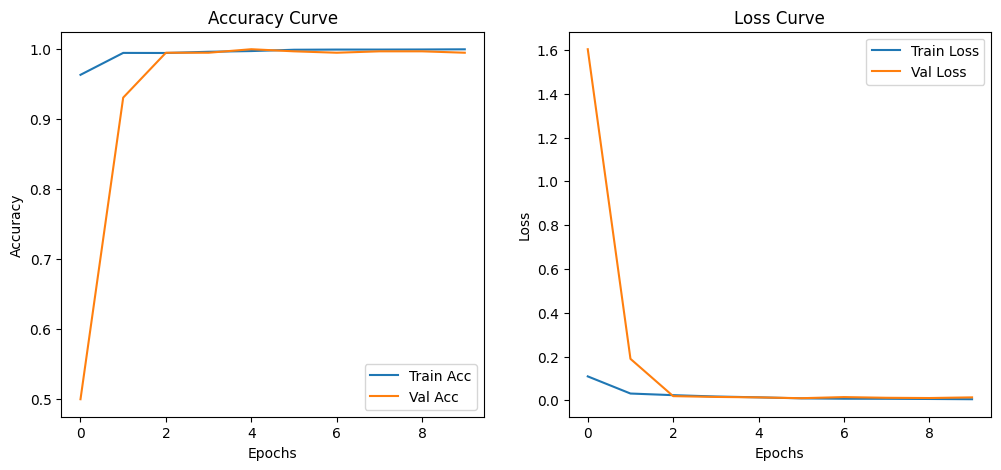

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 373ms/step


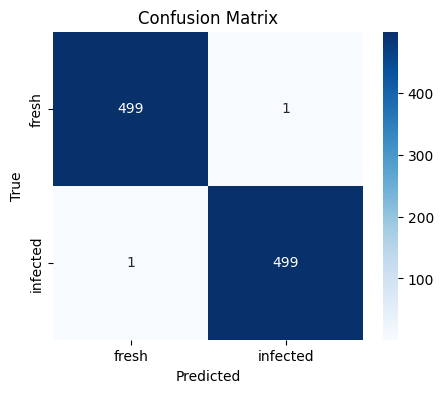


Classification Report:

              precision    recall  f1-score   support

       fresh     0.9980    0.9980    0.9980       500
    infected     0.9980    0.9980    0.9980       500

    accuracy                         0.9980      1000
   macro avg     0.9980    0.9980    0.9980      1000
weighted avg     0.9980    0.9980    0.9980      1000


🔹 Macro Average Accuracy (Precision Avg) : 0.9980
🔹 Overall Test Accuracy: 0.9980


In [ ]:
# --------------------------
# CNN (Fresh vs Infected) - Complete with Macro Accuracy
# --------------------------
import os
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --------------------------
# Paths & parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (224, 224)
batch_size = 32
epochs = 10   # change if needed

# Class names
class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators
# --------------------------
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# --------------------------
# Refined CNN Model
# --------------------------
model_cnn = Sequential([
    Conv2D(32, (3,3), padding="same", input_shape=(224,224,3)),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), padding="same"),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.5),

    Dense(128),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    Dropout(0.3),

    Dense(len(class_names), activation='softmax')
])

model_cnn.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_cnn_model.keras"  # future-proof format
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Plot Loss & Accuracy
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------
# Evaluation on Test Data (with Macro Accuracy)
# --------------------------
y_pred = model_cnn.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy (Average Precision) & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
print(f"\n🔹 Macro Average Accuracy (Precision Avg) : {macro_accuracy:.4f}")

overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 Overall Test Accuracy: {overall_acc:.4f}")


Classes: ['fresh', 'infected']
Found 8000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,334,594 (27.98 MB)

 Trainable params: 663,490 (2.53 MB)

 Non-trainable params: 6,671,104 (25.45 MB)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 200s 656ms/step - accuracy: 0.7987 - loss: 1.4943 - val_accuracy: 0.9930 - val_loss: 1.0779
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 157s 557ms/step - accuracy: 0.9545 - loss: 1.0686 - val_accuracy: 0.9980 - val_loss: 0.9015
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 159s 624ms/step - accuracy: 0.9822 - loss: 0.9014 - val_accuracy: 0.9980 - val_loss: 0.8035
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 144s 574ms/step - accuracy: 0.9905 - loss: 0.8048 - val_accuracy: 0.9980 - val_loss: 0.7385
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 147s 587ms/step - accuracy: 0.9941 - loss: 0.7384 - val_accuracy: 0.9990 - val_loss: 0.6901
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 149s 597ms/step - accuracy: 0.9956 - loss: 0.6893 - val_accuracy: 0.9990 - val_loss: 0.6502
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 142s 569ms/step - accuracy: 0.9965 - loss: 0.6501 - val_accuracy: 0.9990 - val_loss: 0.6158
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 138s 552ms/step - accuracy: 0.9967 -

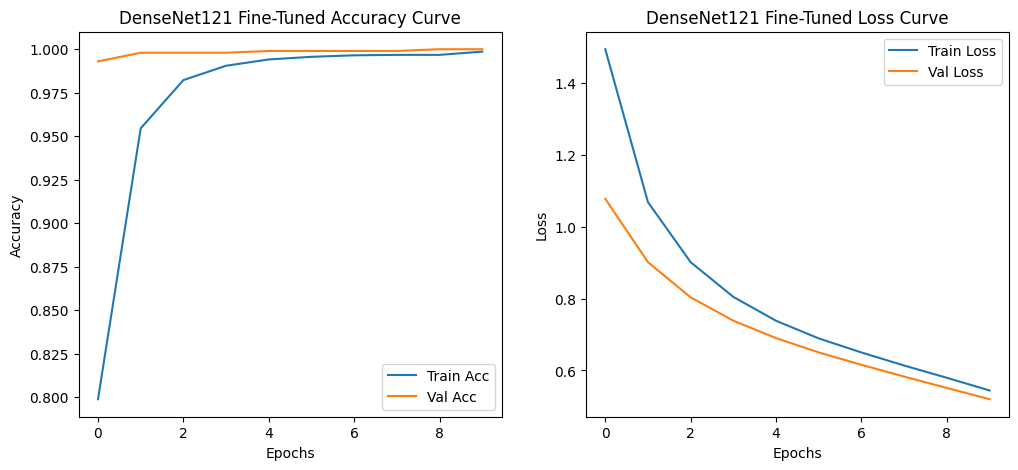

32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 789ms/step


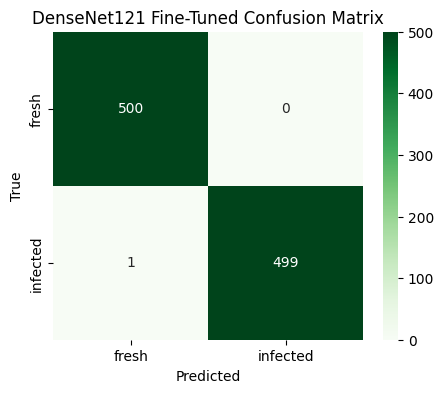


DenseNet121 Fine-Tuned Classification Report:

              precision    recall  f1-score   support

       fresh     0.9980    1.0000    0.9990       500
    infected     1.0000    0.9980    0.9990       500

    accuracy                         0.9990      1000
   macro avg     0.9990    0.9990    0.9990      1000
weighted avg     0.9990    0.9990    0.9990      1000

🔹 DenseNet121 Macro Average Accuracy: 0.9990
🔹 DenseNet121 Overall Test Accuracy: 0.9990


In [ ]:
# --------------------------
# Refined DenseNet121 (Target Accuracy ~95–98%)
# --------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --------------------------
# Paths & Parameters
# --------------------------
output_dir = "/content/Final_split"
img_size = (128, 128)  # smaller image size to reduce overfitting
batch_size = 32
epochs = 10

class_names = sorted(os.listdir(os.path.join(output_dir, "train")))
print("Classes:", class_names)

# --------------------------
# Data Generators (Stronger Augmentation)
# --------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False
)

# --------------------------
# Base DenseNet121 Model
# --------------------------
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))

# Freeze most layers (only fine-tune last 20 layers)
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Custom Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.002))(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.6)(x)
x = Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.002))(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)
x = Dropout(0.4)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

model_densenet = Model(inputs=base_model.input, outputs=predictions)

# --------------------------
# Compile Model
# --------------------------
model_densenet.compile(
    optimizer=Adam(learning_rate=5e-5),  # smaller LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_densenet.summary()

# --------------------------
# Callbacks
# --------------------------
checkpoint_path = "best_refined_densenet121_v2.keras"
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

# --------------------------
# Train Model
# --------------------------
history = model_densenet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks
)

# --------------------------
# Plot Accuracy & Loss
# --------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("DenseNet121 Fine-Tuned Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("DenseNet121 Fine-Tuned Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --------------------------
# Evaluation on Test Data
# --------------------------
y_pred = model_densenet.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DenseNet121 Fine-Tuned Confusion Matrix")
plt.show()

report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print("\nDenseNet121 Fine-Tuned Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

# --------------------------
# Macro Accuracy & Overall Accuracy
# --------------------------
macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 DenseNet121 Macro Average Accuracy: {macro_accuracy:.4f}")
print(f"🔹 DenseNet121 Overall Test Accuracy: {overall_acc:.4f}")


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# --------------------------
# Feature Extraction with DenseNet121
# --------------------------
# Assuming train_gen is the full dataset generator (images + labels)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128,128,3)) # Changed input_shape to (128, 128, 3)
x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Function to extract features
def extract_features(generator):
    features, labels = [], []
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = feature_extractor.predict(x_batch, verbose=0)
        features.append(feat)
        labels.append(y_batch)
    features = np.vstack(features)
    labels = np.hstack(labels)
    return features, labels

print("Extracting features from full dataset...")
X, y = extract_features(train_gen)

# --------------------------
# 10-Fold Cross Validation
# --------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

precisions, recalls, f1s, accuracies = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_fold, y_train_fold)
    y_pred_fold = clf.predict(X_val_fold)

    precision = precision_score(y_val_fold, y_pred_fold, average='macro')
    recall = recall_score(y_val_fold, y_pred_fold, average='macro')
    f1 = f1_score(y_val_fold, y_pred_fold, average='macro')
    acc = accuracy_score(y_val_fold, y_pred_fold)

    # Print fold metrics
    print(f"Fold {fold}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, Accuracy={acc:.4f}")

    # Save for overall average
    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    accuracies.append(acc)

# --------------------------
# Average metrics across folds
# --------------------------
print("\n===== 10-Fold CV Average Metrics =====")
print(f"Macro Precision: {np.mean(precisions):.4f}")
print(f"Macro Recall:    {np.mean(recalls):.4f}")
print(f"Macro F1-score:  {np.mean(f1s):.4f}")
print(f"Accuracy:        {np.mean(accuracies):.4f}")

Extracting features from full dataset...
Fold 1: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 2: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 3: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 4: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 5: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 6: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 7: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 8: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 9: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 10: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988

===== 10-Fold CV Average Metrics =====
Macro Precision: 0.9989
Macro Recall:    0.9989
Macro F1-score:  0.9989
Accuracy:        0.9989


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# --------------------------
# Feature Extraction (DenseNet121)
# --------------------------
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128,128,3))
x = GlobalAveragePooling2D()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

for layer in base_model.layers:
    layer.trainable = False

def extract_features(generator):
    features, labels = [], []
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        feat = feature_extractor.predict(x_batch, verbose=0)
        features.append(feat)
        labels.append(y_batch)
    features = np.vstack(features)
    labels = np.hstack(labels)
    return features, labels

print("Extracting DenseNet121 features from dataset...")
X, y = extract_features(train_gen)  # use full dataset generator

# --------------------------
# Classifiers
# --------------------------
classifiers = {
    "SVM": SVC(kernel='linear', probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
}

# --------------------------
# 10-Fold Cross Validation
# --------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, clf in classifiers.items():
    print(f"\n===== {name} 10-Fold CV =====")
    precisions, recalls, f1s, accuracies = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]

        clf.fit(X_train_fold, y_train_fold)
        y_pred_fold = clf.predict(X_val_fold)

        precision = precision_score(y_val_fold, y_pred_fold, average='macro')
        recall = recall_score(y_val_fold, y_pred_fold, average='macro')
        f1 = f1_score(y_val_fold, y_pred_fold, average='macro')
        acc = accuracy_score(y_val_fold, y_pred_fold)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        accuracies.append(acc)

        print(f"Fold {fold}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, Accuracy={acc:.4f}")

    print(f"\n{name} 10-Fold Average: Precision={np.mean(precisions):.4f}, Recall={np.mean(recalls):.4f}, F1={np.mean(f1s):.4f}, Accuracy={np.mean(accuracies):.4f}")

Extracting DenseNet121 features from dataset...

===== SVM 10-Fold CV =====
Fold 1: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 2: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 3: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 4: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 5: Precision=1.0000, Recall=1.0000, F1=1.0000, Accuracy=1.0000
Fold 6: Precision=0.9975, Recall=0.9975, F1=0.9975, Accuracy=0.9975
Fold 7: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 8: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 9: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988
Fold 10: Precision=0.9988, Recall=0.9988, F1=0.9987, Accuracy=0.9988

SVM 10-Fold Average: Precision=0.9989, Recall=0.9989, F1=0.9989, Accuracy=0.9989

===== KNN 10-Fold CV =====
Fold 1: Precision=0.9963, Recall=0.9963, F1=0.9962, Accuracy=0.9962
Fold 2: Precision=0.9963, Recall=0.9963, F1=0.9962, Accuracy=0.99

KeyboardInterrupt: 

In [ ]:
0.997024  0.997006  0.997006  0.997006

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 162s 525ms/step - accuracy: 0.4914 - loss: 0.6979 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 115s 458ms/step - accuracy: 0.5025 - loss: 0.6949 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 431ms/step - accuracy: 0.5044 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6944
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 435ms/step - accuracy: 0.4997 - loss: 0.6943 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 418ms/step - accuracy: 0.5009 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 447ms/step - accuracy: 0.5110 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 434ms/step - accuracy: 0.4999 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 107s 427ms/step - accuracy: 0.4988 -

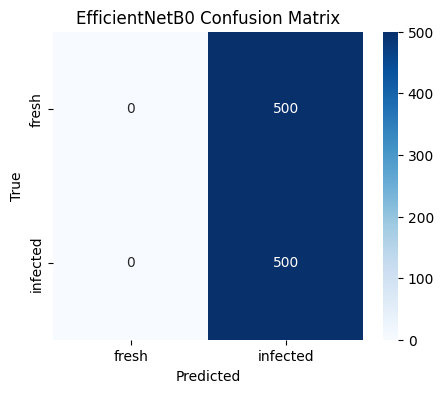

              precision    recall  f1-score   support

       fresh     0.0000    0.0000    0.0000       500
    infected     0.5000    1.0000    0.6667       500

    accuracy                         0.5000      1000
   macro avg     0.2500    0.5000    0.3333      1000
weighted avg     0.2500    0.5000    0.3333      1000

🔹 Macro Average Accuracy: 0.2500
🔹 Overall Test Accuracy: 0.5000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import tensorflow as tf
import os

# Paths & parameters
output_dir = "/content/Final_split"
img_size = (224, 224)

# Class names
class_names = sorted(os.listdir(os.path.join(output_dir, "train")))

# Base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)   # Increase dense layer size
x = Dropout(0.3)(x)                    # Reduce dropout rate
predictions = Dense(len(class_names), activation='softmax')(x)

model_efficient = Model(inputs=base_model.input, outputs=predictions)

# Freeze base
for layer in base_model.layers:
    layer.trainable = False

# Compile
model_efficient.compile(optimizer=Adam(1e-4),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Train
history = model_efficient.fit(train_gen, validation_data=val_gen, epochs=10)

# Evaluate
y_pred = model_efficient.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

# Classification report
report = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4, output_dict=True)
print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

macro_accuracy = np.mean([report[cls]['precision'] for cls in class_names])
overall_acc = np.mean(y_true == y_pred_classes)
print(f"🔹 Macro Average Accuracy: {macro_accuracy:.4f}")
print(f"🔹 Overall Test Accuracy: {overall_acc:.4f}")